# SHAP Explainability for CVD Risk Classification XGBoost Model
===============================================================

This notebook provides a complete explainability analysis using SHAP (SHapley Additive exPlanations) for the XGBoost binary classification model (`best_model.pkl`).

### Objectives:
1. Load the trained XGBoost model, the StandardScaler, and the clean dataset.
2. Generate SHAP values using `shap.TreeExplainer`.
3. Create and save 4 standard SHAP visualizations (Beeswarm, Bar, and 2 Waterfall plots).
4. Save SHAP values and feature importances as CSV files.
5. Print a detailed risk explanation for high and low risk patients in human-interpretable units.

In [1]:
# ============================================================
# BLOCK 1: IMPORTS & VERSION CHECK
# ============================================================
import pandas as pd
import numpy as np
import joblib
import shap
import os
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split

print('Pandas version: ', pd.__version__)
print('NumPy version:  ', np.__version__)
print('SHAP version:   ', shap.__version__)

Pandas version:  2.2.2
NumPy version:   1.26.4
SHAP version:    0.52.0


## Load Model, Scaler, and Test Data
Here we load the trained XGBoost model, the scaler, and the clean dataset. We then recreate the exact train/test split (20% test, `random_state=42`, stratified by target).

In [2]:
# ============================================================
# BLOCK 2: LOAD FILES & RECREATE SPLIT
# ============================================================
data_dir = '../data/processed/'
images_dir = '../images/'
os.makedirs(images_dir, exist_ok=True)

# Load files
best_model = joblib.load(os.path.join(data_dir, 'best_model.pkl'))
scaler = joblib.load(os.path.join(data_dir, 'scaler.pkl'))
df = pd.read_csv(os.path.join(data_dir, 'processed_data_clean.csv'))

print(f"Loaded dataset shape: {df.shape}")

# Extract features and target
feature_cols = [col for col in df.columns if col != 'CVD_Risk_Encoded']
X = df[feature_cols]
y = df['CVD_Risk_Encoded'].astype(int)

# Exact split matching model training
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Recreated Test set size: {X_test.shape[0]} samples")
print(f"Test Target Distribution:\n{y_test.value_counts().rename({0: 'INTERMEDIARY', 1: 'HIGH'}).to_dict()}")

Loaded dataset shape: (1309, 33)
Recreated Test set size: 262 samples
Test Target Distribution:
{'HIGH': 146, 'INTERMEDIARY': 116}


## Generate SHAP Values using TreeExplainer
We use SHAP's `TreeExplainer` which computes exact Shapley values for tree ensemble models.

In [3]:
# ============================================================
# BLOCK 3: GENERATE SHAP VALUES
# ============================================================
explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_test)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Base value (expected log-odds): {explainer.expected_value:.6f}")

SHAP values shape: (262, 32)
Base value (expected log-odds): -0.011074


## Reconstruct Unscaled Features for Visualization
To make the SHAP explanations human-interpretable, we use the loaded scaler to inverse-transform the scaled features back to their original physical units (like Age in years, Weight in kg, BP in mmHg) on the plot labels.

In [4]:
# ============================================================
# BLOCK 4: UNSCALING FEATURES & UPDATING SHAP EXPLANATION
# ============================================================
scale_cols = [
    'Age', 'Weight (kg)', 'Height (m)', 'BMI',
    'Abdominal Circumference (cm)', 'Total Cholesterol (mg/dL)',
    'HDL (mg/dL)', 'Fasting Blood Sugar (mg/dL)',
    'Waist-to-Height Ratio', 'Systolic BP', 'Diastolic BP',
    'CVD Risk Score', 'Pulse Pressure', 'Cholesterol_HDL_Ratio',
    'Metabolic_Score', 'Physical_Activity_Encoded'
]

# Create unscaled DataFrame
X_test_unscaled = X_test.copy()
X_test_unscaled[scale_cols] = scaler.inverse_transform(X_test[scale_cols])

# Re-create a new Explanation object containing unscaled feature data
shap_values_unscaled = shap.Explanation(
    values=shap_values.values,
    base_values=shap_values.base_values,
    data=X_test_unscaled.values,
    feature_names=feature_cols
)
print("Created shap.Explanation object with unscaled features.")

Created shap.Explanation object with unscaled features.


## Create and Save SHAP Visualizations
We generate the 4 required SHAP plots and save them to the `images/` directory.

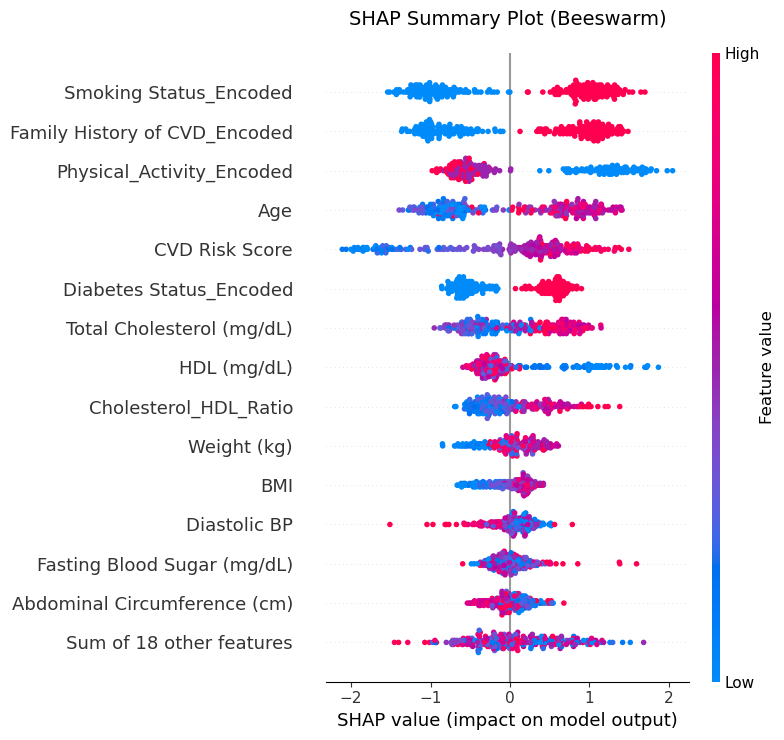

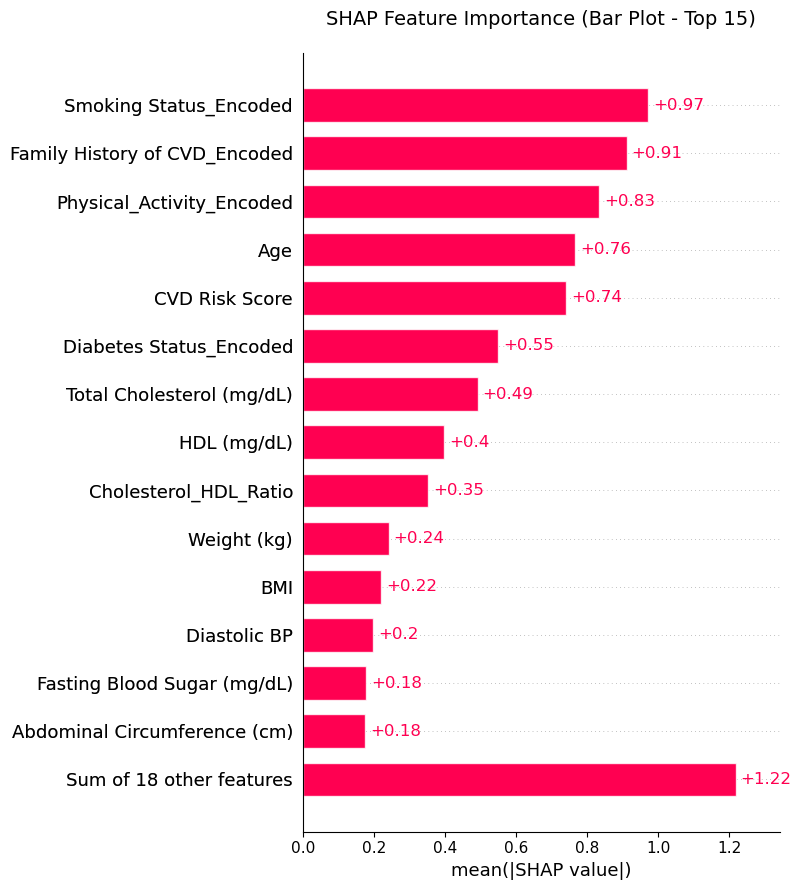

Selected HIGH Risk Patient Index: 0
Selected LOW Risk Patient Index:  2


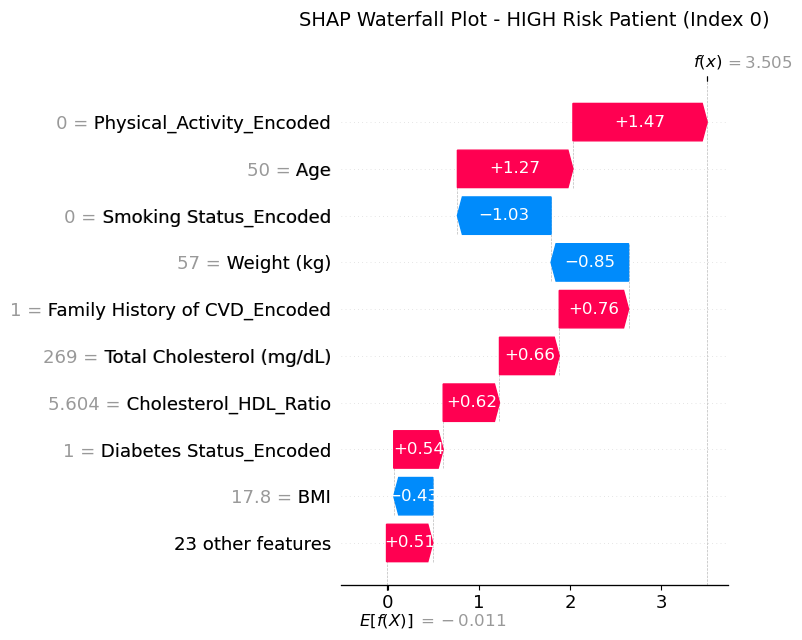

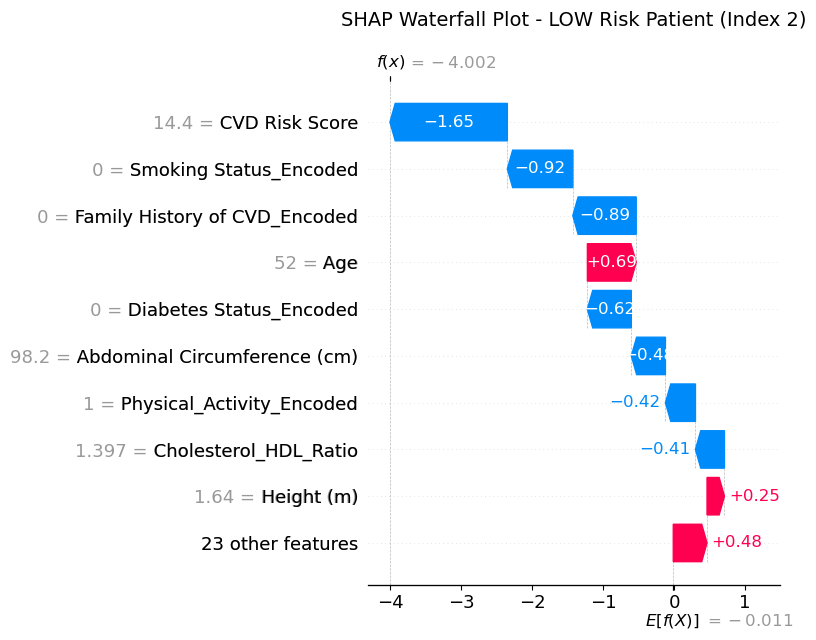

In [5]:
# ============================================================
# BLOCK 5: GENERATE & SAVE PLOTS
# ============================================================
# Get model predictions & probabilities on the test set
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# 1. SHAP Summary Plot (Beeswarm)
plt.figure(figsize=(10, 8))
shap.plots.beeswarm(shap_values_unscaled, max_display=15, show=False)
plt.title("SHAP Summary Plot (Beeswarm)", fontsize=14, pad=20)
plt.tight_layout()
plt.savefig(os.path.join(images_dir, 'shap_summary_plot.png'), bbox_inches='tight', dpi=300)
plt.show()
plt.close()

# 2. SHAP Bar Plot (Top 15 features)
plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values_unscaled, max_display=15, show=False)
plt.title("SHAP Feature Importance (Bar Plot - Top 15)", fontsize=14, pad=20)
plt.tight_layout()
plt.savefig(os.path.join(images_dir, 'shap_bar_plot.png'), bbox_inches='tight', dpi=300)
plt.show()
plt.close()

# Patient selection with fallback logic
high_risk_indices = np.where((y_test == 1) & (y_pred == 1))[0]
if len(high_risk_indices) > 0:
    high_risk_idx = high_risk_indices[0]
else:
    high_risk_idx = np.where(y_pred == 1)[0][0]

low_risk_indices = np.where((y_test == 0) & (y_pred == 0))[0]
if len(low_risk_indices) > 0:
    low_risk_idx = low_risk_indices[0]
else:
    low_risk_idx = np.where(y_pred == 0)[0][0]

print(f"Selected HIGH Risk Patient Index: {high_risk_idx}")
print(f"Selected LOW Risk Patient Index:  {low_risk_idx}")

# 3. SHAP Waterfall Plot (HIGH Risk Patient)
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values_unscaled[high_risk_idx], show=False)
plt.title(f"SHAP Waterfall Plot - HIGH Risk Patient (Index {high_risk_idx})", fontsize=14, pad=20)
plt.tight_layout()
plt.savefig(os.path.join(images_dir, 'shap_waterfall_high_risk.png'), bbox_inches='tight', dpi=300)
plt.show()
plt.close()

# 4. SHAP Waterfall Plot (LOW Risk Patient)
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values_unscaled[low_risk_idx], show=False)
plt.title(f"SHAP Waterfall Plot - LOW Risk Patient (Index {low_risk_idx})", fontsize=14, pad=20)
plt.tight_layout()
plt.savefig(os.path.join(images_dir, 'shap_waterfall_low_risk.png'), bbox_inches='tight', dpi=300)
plt.show()
plt.close()

## Export SHAP Values and Feature Importance to CSV
We save the output data to the processed data directory.

In [6]:
# ============================================================
# BLOCK 6: SAVE CSV FILES
# ============================================================
# Export SHAP Values matrix
df_shap = pd.DataFrame(shap_values.values, columns=feature_cols)
df_shap.to_csv(os.path.join(data_dir, 'shap_values.csv'), index=False)
print(f"Saved SHAP Values to: {os.path.join(data_dir, 'shap_values.csv')}")

# Export global SHAP Feature Importance
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
df_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Mean_Abs_SHAP': mean_abs_shap
}).sort_values(by='Mean_Abs_SHAP', ascending=False)

df_importance.to_csv(os.path.join(data_dir, 'shap_feature_importance.csv'), index=False)
print(f"Saved SHAP Feature Importance to: {os.path.join(data_dir, 'shap_feature_importance.csv')}")

Saved SHAP Values to: ../data/processed/shap_values.csv
Saved SHAP Feature Importance to: ../data/processed/shap_feature_importance.csv


## Print Detailed Risk Explanation & Summary Table
Here we print the text explanation for the chosen HIGH risk patient, converting values from log-odds to risk probabilities, and print a summary table of feature importance.

In [7]:
# ============================================================
# BLOCK 7: PRINT EXPLANATIONS & TABLE
# ============================================================
# Sigmoid function to convert log-odds to probability
def log_odds_to_prob(log_odds):
    return 1 / (1 + np.exp(-log_odds))

idx = high_risk_idx
patient_shap = shap_values_unscaled[idx]

# Details
actual_val = y_test.iloc[idx]
actual_label = 'HIGH RISK' if actual_val == 1 else 'INTERMEDIARY RISK'
pred_val = y_pred[idx]
pred_label = 'HIGH RISK' if pred_val == 1 else 'INTERMEDIARY RISK'
prob_val = y_pred_proba[idx]

base_log_odds = patient_shap.base_values
final_log_odds = base_log_odds + patient_shap.values.sum()

base_prob = log_odds_to_prob(base_log_odds)
final_prob = log_odds_to_prob(final_log_odds)

# Get feature contributions
contributions = []
for i in range(len(feature_cols)):
    contributions.append({
        'feature': feature_cols[i],
        'shap_val': patient_shap.values[i],
        'actual_val': patient_shap.data[i]
    })

# Sort for positive (increasing risk) and negative (decreasing risk)
increasing_contribs = sorted([c for c in contributions if c['shap_val'] > 0], key=lambda x: x['shap_val'], reverse=True)
decreasing_contribs = sorted([c for c in contributions if c['shap_val'] < 0], key=lambda x: x['shap_val'])

# Print explanation
print('='*70)
print(f"DETAILED SHAP RISK EXPLANATION FOR PATIENT INDEX: {idx}")
print('='*70)
print(f"Actual Class:     {actual_val} ({actual_label})")
print(f"Predicted Class:  {pred_val} ({pred_label})")
print(f"Prediction Prob:  {prob_val:.4f} ({prob_val*100:.2f}%)")
print('-'*70)
print(f"Base Value (Expected Risk):  {base_log_odds:.4f} log-odds (Prob: {base_prob*100:.2f}%)")
print(f"Final Value (Predicted Risk): {final_log_odds:.4f} log-odds (Prob: {final_prob*100:.2f}%)")
print('-'*70)

print("Top 3 Features Increasing Risk (Red):")
for i, c in enumerate(increasing_contribs[:3]):
    print(f"  {i+1}. {c['feature']}: {c['shap_val']:+.4f} (Actual Value: {c['actual_val']:.2f})")

print("\nTop 3 Features Decreasing Risk (Blue):")
for i, c in enumerate(decreasing_contribs[:3]):
    print(f"  {i+1}. {c['feature']}: {c['shap_val']:+.4f} (Actual Value: {c['actual_val']:.2f})")
print('='*70)

print('\n' + '='*70)
print("FEATURE IMPORTANCE SUMMARY TABLE (Top 10 Features)")
print('='*70)
print(df_importance.head(10).to_string(index=False))
print('='*70)

DETAILED SHAP RISK EXPLANATION FOR PATIENT INDEX: 0
Actual Class:     1 (HIGH RISK)
Predicted Class:  1 (HIGH RISK)
Prediction Prob:  0.9708 (97.08%)
----------------------------------------------------------------------
Base Value (Expected Risk):  -0.0111 log-odds (Prob: 49.72%)
Final Value (Predicted Risk): 3.5046 log-odds (Prob: 97.08%)
----------------------------------------------------------------------
Top 3 Features Increasing Risk (Red):
  1. Physical_Activity_Encoded: +1.4719 (Actual Value: 0.00)
  2. Age: +1.2667 (Actual Value: 50.00)
  3. Family History of CVD_Encoded: +0.7602 (Actual Value: 1.00)

Top 3 Features Decreasing Risk (Blue):
  1. Smoking Status_Encoded: -1.0268 (Actual Value: 0.00)
  2. Weight (kg): -0.8500 (Actual Value: 57.00)
  3. BMI: -0.4287 (Actual Value: 17.80)

FEATURE IMPORTANCE SUMMARY TABLE (Top 10 Features)
                      Feature  Mean_Abs_SHAP
       Smoking Status_Encoded       0.971738
Family History of CVD_Encoded       0.910838
    Physi